In [9]:
!pip install -q transformers datasets evaluate scikit-learn accelerate peft sentencepiece protobuf
!pip install -U "torchao>=0.16.0" peft transformers datasets evaluate

In [10]:
import os
import random
import numpy as np
import pandas as pd

os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["WANDB_PROJECT"] = "Fact_Checker_Travel"

import torch
from datasets import Dataset, DatasetDict
from transformers import (AutoTokenizer, AutoModelForSequenceClassification, 
                          TrainingArguments, Trainer, DataCollatorWithPadding, 
                          pipeline, EarlyStoppingCallback)
from peft import get_peft_model, LoraConfig, TaskType,PromptTuningConfig, PromptTuningInit
import evaluate
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score


SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True; torch.backends.cudnn.benchmark = False

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Device: {DEVICE}")

def reset_seeds(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

try:
    import wandb
    from kaggle_secrets import UserSecretsClient
    wandb.login(key=UserSecretsClient().get_secret("WANDB_API_KEY"))
    
    REPORT_TO = "wandb"
    print("W&B attivato.")
except Exception as e:
    print(f"W&B disabilitato. ({e})")
    os.environ["WANDB_DISABLED"] = "true"
    REPORT_TO = "none"

Device: cuda


wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


W&B attivato.


In [11]:
from datasets import Dataset, DatasetDict, ClassLabel

df = pd.read_csv('/kaggle/input/datasets/gabrieelee/factcheck-dataset-japan-csv/factcheck_dataset_japan.csv')
df = df.rename(columns={"context": "premise", "claim": "hypothesis"})

ID2LABEL = {0: "contradiction", 1: "entailment", 2: "neutral_hard"}
LABEL2ID = {v: k for k, v in ID2LABEL.items()}
NUM_LABELS = len(ID2LABEL)

dataset = Dataset.from_pandas(df)
train_test = dataset.train_test_split(test_size=0.3, seed=SEED)
val_test = train_test['test'].train_test_split(test_size=0.5, seed=SEED)
ds = DatasetDict({'train': train_test['train'], 'validation': val_test['train'], 'test': val_test['test']})

rows = []
for split in ["train", "validation", "test"]:
    counts = pd.Series(ds[split]["label"]).value_counts().sort_index()
    row = {ID2LABEL[i]: int(counts.get(i, 0)) for i in ID2LABEL}   
    row["Totale"] = len(ds[split])
    rows.append(row)

dist = pd.DataFrame(rows, index=["train", "validation", "test"])
dist.loc["TOTALE"] = dist.sum()

print("\nConteggio esempi per split e per label:")
print(dist)

train_labels = ds['train']['label']
counts = pd.Series(train_labels).value_counts().sort_index().values.astype(float)
class_weights = torch.tensor(counts.sum() / (NUM_LABELS * counts), dtype=torch.float).to(DEVICE)
print("\n\n Pesi calcolati per le classi (Contradiction, Entailment, Neutral):", class_weights.tolist())

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        loss = torch.nn.functional.cross_entropy(outputs.logits.float(), labels, weight=class_weights.float())
        return (loss, outputs) if return_outputs else loss


Conteggio esempi per split e per label:
            contradiction  entailment  neutral_hard  Totale
train                 211         216           258     685
validation             44          46            57     147
test                   45          40            62     147
TOTALE                300         302           377     979


 Pesi calcolati per le classi (Contradiction, Entailment, Neutral): [1.082148551940918, 1.0570987462997437, 0.8850129246711731]


In [12]:
model_checkpoint = "/kaggle/input/datasets/gabrieelee/mdeberta-v3-base-mnli-xnli-offline"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

def tokenize_function(examples):
    return tokenizer(
        examples["premise"], 
        examples["hypothesis"], 
        truncation=True, 
        max_length=256
    )

tokenized_ds = ds.map(tokenize_function, batched=True)
colonne_da_rimuovere = [c for c in ["fact_id", "premise", "hypothesis", "claim_type", "__index_level_0__"] if c in tokenized_ds["train"].column_names]
tokenized_ds = tokenized_ds.remove_columns(colonne_da_rimuovere)
tokenized_ds.set_format("torch")

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

import evaluate
metric_acc = evaluate.load("accuracy")
metric_f1 = evaluate.load("f1")

def compute_metrics(eval_pred):
    preds = np.argmax(eval_pred.logits if hasattr(eval_pred, 'logits') else eval_pred.predictions, axis=-1)
    acc = metric_acc.compute(predictions=preds, references=eval_pred.label_ids)["accuracy"]
    f1 = metric_f1.compute(predictions=preds, references=eval_pred.label_ids, average="macro")["f1"]
    return {"accuracy": acc, "macro_f1": f1}

Map:   0%|          | 0/685 [00:00<?, ? examples/s]

Map:   0%|          | 0/147 [00:00<?, ? examples/s]

Map:   0%|          | 0/147 [00:00<?, ? examples/s]

In [13]:
print("--- CALCOLO BASELINE SUL TEST SET ---")

nli_pipe = pipeline("text-classification", model="/kaggle/input/datasets/gabrieelee/mdeberta-v3-base-mnli-xnli-offline", device=0 if DEVICE=="cuda" else -1)

def map_nli_label(label_str):
    if "entailment" in label_str.lower(): return 1
    if "contradiction" in label_str.lower(): return 0
    return 2

zero_shot_preds, true_labels = [], []
for item in ds["test"]:
    text = f"{item['premise']} {nli_pipe.tokenizer.sep_token} {item['hypothesis']}"
    res = nli_pipe(text, truncation=True, max_length=256)[0]
    zero_shot_preds.append(map_nli_label(res['label']))
    true_labels.append(item['label'])

zs_acc = metric_acc.compute(predictions=zero_shot_preds, references=true_labels)["accuracy"]
zs_f1 = metric_f1.compute(predictions=zero_shot_preds, references=true_labels, average="macro")["f1"]
print(f"Baseline (Zero-Shot mDeBERTa) - Accuracy: {zs_acc:.4f}, Macro-F1: {zs_f1:.4f}")

del nli_pipe
torch.cuda.empty_cache()

--- CALCOLO BASELINE SUL TEST SET ---


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

Baseline (Zero-Shot mDeBERTa) - Accuracy: 0.8980, Macro-F1: 0.8945


In [14]:

print("\n Avvio Ricerca Iperparametri LoRA sul Validation Set (Con Early Stopping)...")

results_log = []
lora_ranks = [8,16]
learning_rates = [1e-4,2e-4, 3e-4]

best_f1 = 0
best_config = {}

for r in lora_ranks:
    for lr in learning_rates:
        print(f"\n Test -> Rank: {r}, LR: {lr}")
        reset_seeds(SEED)
        lora_config = LoraConfig(
            r=r, 
            lora_alpha=16, 
            lora_dropout=0.2, 
            bias="none", 
            task_type=TaskType.SEQ_CLS,
            target_modules=["query_proj", "key_proj", "value_proj", "output_proj","dense_h_to_4h", "dense_4h_to_h"]
        )
        
        temp_model = AutoModelForSequenceClassification.from_pretrained( model_checkpoint, num_labels=NUM_LABELS, id2label=ID2LABEL, label2id=LABEL2ID)
        temp_model = get_peft_model(temp_model, lora_config)
        training_args = TrainingArguments(
            output_dir=f"./lora_search_r{r}_lr{lr}", 
            learning_rate=lr,
            per_device_train_batch_size=8, 
            per_device_eval_batch_size=8,
            num_train_epochs=10,                      
            eval_strategy="epoch", 
            save_strategy="epoch",                   
            load_best_model_at_end=True,             
            metric_for_best_model="macro_f1",
            greater_is_better=True,
            report_to="none" 
        )
        
        temp_trainer = WeightedTrainer(
            model=temp_model, args=training_args,
            train_dataset=tokenized_ds["train"], eval_dataset=tokenized_ds["validation"],
            processing_class=tokenizer, data_collator=data_collator, compute_metrics=compute_metrics,
            callbacks=[EarlyStoppingCallback(early_stopping_patience=2)] 
        )
        
        temp_trainer.train()
        
        val_result = temp_trainer.evaluate()
        val_f1 = val_result['eval_macro_f1']
        
        results_log.append({
            "Rank": r, "LR": lr, 
            "Epoca_Fermata": temp_trainer.state.epoch, 
            "Val_Accuracy": val_result['eval_accuracy'], 
            "Val_Macro_F1": val_f1
        })
        
        if val_f1 > best_f1:
            best_f1 = val_f1
            best_config = {'r': r, 'lr': lr}

print(f"\n Miglior configurazione: {best_config} (Val Macro F1: {best_f1:.4f})")
display(pd.DataFrame(results_log).sort_values("Val_Macro_F1", ascending=False))


 Avvio Ricerca Iperparametri LoRA sul Validation Set (Con Early Stopping)...

 Test -> Rank: 8, LR: 0.0001


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 1}.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,No log,1.301043,0.448980,0.390670
2,No log,0.329573,0.897959,0.888908
3,No log,0.178938,0.952381,0.948597
4,No log,0.107592,0.972789,0.970845
5,No log,0.097870,0.965986,0.964242
6,0.827539,0.114887,0.972789,0.970845


Training Loss,Validation Loss,Epoch,Accuracy,Macro F1
0.827539,0.107592,6,0.972789,0.970845


...

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 1}.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,No log,0.179138,0.945578,0.942014
2,No log,0.147777,0.972789,0.970845
3,No log,0.188867,0.965986,0.963892
4,No log,0.098930,0.972789,0.971146
5,No log,0.207917,0.972789,0.970845
6,0.411461,0.274010,0.965986,0.963892


Training Loss,Validation Loss,Epoch,Accuracy,Macro F1
0.411461,0.098930,6,0.972789,0.971146



 Miglior configurazione: {'r': 8, 'lr': 0.0003} (Val Macro F1: 0.9782)


,Rank,LR,Epoca_Fermata,Val_Accuracy,Val_Macro_F1
2,8,0.0003,4.0,0.979592,0.978245
4,16,0.0002,6.0,0.979592,0.977753
5,16,0.0003,6.0,0.972789,0.971146
0,8,0.0001,6.0,0.972789,0.970845
3,16,0.0001,8.0,0.972789,0.970845
1,8,0.0002,6.0,0.972789,0.970312


In [15]:
print(f"\n Avvio addestramento finale con Rank {best_config['r']} e LR {best_config['lr']}...")

final_lora_config = LoraConfig(
    r=best_config['r'], 
    lora_alpha=16, 
    lora_dropout=0.2, 
    bias="none", 
    task_type=TaskType.SEQ_CLS,
    target_modules=["query_proj", "key_proj", "value_proj", "output_proj","dense_h_to_4h", "dense_4h_to_h"]
)

final_model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint, num_labels=NUM_LABELS, id2label=ID2LABEL, label2id=LABEL2ID)
final_model = get_peft_model(final_model, final_lora_config)
final_training_args = TrainingArguments(
    output_dir="./lora_best_model",
    learning_rate=best_config['lr'],
    per_device_train_batch_size=8, 
    per_device_eval_batch_size=8,
    num_train_epochs=15, 
    eval_strategy="epoch",
    logging_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True, metric_for_best_model="macro_f1",
    weight_decay=0.01,         
    warmup_ratio=0.1,
    report_to=REPORT_TO
)

final_trainer = WeightedTrainer(
    model=final_model, args=final_training_args,
    train_dataset=tokenized_ds["train"], eval_dataset=tokenized_ds["validation"],
    processing_class=tokenizer, data_collator=data_collator, compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)] 
)
lora_trainable_params = final_model.num_parameters(only_trainable=True)
lora_total_params = final_model.num_parameters()
print(f"LoRA - trainable: {lora_trainable_params:,} | total: {lora_total_params:,} | trainable%: {lora_trainable_params/lora_total_params*100:.2f}%")

final_trainer.train()
print(f"Il miglior checkpoint è stato caricato automaticamente in memoria grazie a load_best_model_at_end.")

print("\n Valutazione sul TEST SET con il miglior modello...")
final_test_result = final_trainer.evaluate(eval_dataset=tokenized_ds["test"])

print(f"Risultati sul Test Set -> Accuracy: {final_test_result['eval_accuracy']:.4f} | Macro F1: {final_test_result['eval_macro_f1']:.4f}")


 Avvio addestramento finale con Rank 8 e LR 0.0003...


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 1}.


LoRA - trainable: 444,675 | total: 279,256,326 | trainable%: 0.16%


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,4.235633,1.170971,0.360544,0.262763
2,0.549352,0.191405,0.938776,0.934773
3,0.135083,0.067746,0.979592,0.977775
4,0.079679,0.098046,0.979592,0.977753
5,0.034090,0.109313,0.979592,0.977753
6,0.022269,0.088926,0.972789,0.970312


Il miglior checkpoint è stato caricato automaticamente in memoria grazie a load_best_model_at_end.

 Valutazione sul TEST SET con il miglior modello...


Training Loss,Validation Loss,Epoch,Accuracy,Macro F1
0.022269,0.087899,6,0.979592,0.977709


Risultati sul Test Set -> Accuracy: 0.9796 | Macro F1: 0.9777



 Metriche dettagliate per Zero-Shot (baseline)
Accuracy: 0.8980
Precision (macro): 0.8967 | Recall (macro): 0.8952 | F1 (macro): 0.8945
Precision (weighted): 0.8982 | Recall (weighted): 0.8980 | F1 (weighted): 0.8968

 Classification Report per classe (Zero-Shot):
               precision    recall  f1-score   support

contradiction       0.90      0.80      0.85        45
   entailment       0.88      0.95      0.92        40
 neutral_hard       0.91      0.94      0.92        62

     accuracy                           0.90       147
    macro avg       0.90      0.90      0.89       147
 weighted avg       0.90      0.90      0.90       147



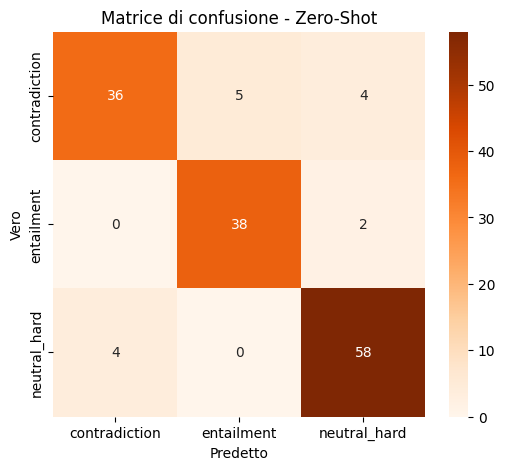

In [16]:
print("\n Metriche dettagliate per Zero-Shot (baseline)")


prec_macro_zs = precision_score(true_labels, zero_shot_preds, average='macro')
rec_macro_zs = recall_score(true_labels, zero_shot_preds, average='macro')
f1_macro_zs = f1_score(true_labels, zero_shot_preds, average='macro')

prec_weighted_zs = precision_score(true_labels, zero_shot_preds, average='weighted')
rec_weighted_zs = recall_score(true_labels, zero_shot_preds, average='weighted')
f1_weighted_zs = f1_score(true_labels, zero_shot_preds, average='weighted')

print(f"Accuracy: {zs_acc:.4f}")
print(f"Precision (macro): {prec_macro_zs:.4f} | Recall (macro): {rec_macro_zs:.4f} | F1 (macro): {f1_macro_zs:.4f}")
print(f"Precision (weighted): {prec_weighted_zs:.4f} | Recall (weighted): {rec_weighted_zs:.4f} | F1 (weighted): {f1_weighted_zs:.4f}")


print("\n Classification Report per classe (Zero-Shot):")
print(classification_report(true_labels, zero_shot_preds, target_names=ID2LABEL.values()))


cm_zs = confusion_matrix(true_labels, zero_shot_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm_zs, annot=True, fmt='d', cmap='Oranges',xticklabels=ID2LABEL.values(), yticklabels=ID2LABEL.values())
plt.title("Matrice di confusione - Zero-Shot")
plt.xlabel("Predetto")
plt.ylabel("Vero")
plt.show()


 Metriche dettagliate per LoRA sul test set


LoRA - trainable: 444,675 | total: 279,256,326 | trainable%: 0.16%
Accuracy: 0.9796
Precision (macro): 0.9788 | Recall (macro): 0.9778 | F1 (macro): 0.9777
Precision (weighted): 0.9803 | Recall (weighted): 0.9796 | F1 (weighted): 0.9794

 Classification Report per classe (LoRA):
               precision    recall  f1-score   support

contradiction       1.00      0.93      0.97        45
   entailment       0.95      1.00      0.98        40
 neutral_hard       0.98      1.00      0.99        62

     accuracy                           0.98       147
    macro avg       0.98      0.98      0.98       147
 weighted avg       0.98      0.98      0.98       147



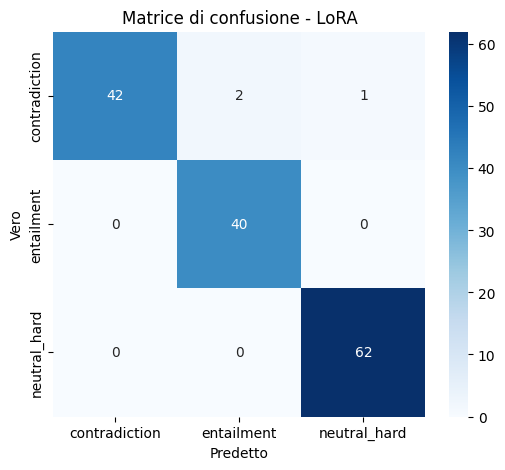

In [17]:

print("\n Metriche dettagliate per LoRA sul test set")

predictions_lora = final_trainer.predict(tokenized_ds["test"])
preds_lora = np.argmax(predictions_lora.predictions, axis=-1)
refs = np.array(ds["test"]["label"])

acc_lora = accuracy_score(refs, preds_lora)
prec_macro_lora = precision_score(refs, preds_lora, average='macro')
rec_macro_lora = recall_score(refs, preds_lora, average='macro')
f1_macro_lora = f1_score(refs, preds_lora, average='macro')

prec_weighted_lora = precision_score(refs, preds_lora, average='weighted')
rec_weighted_lora = recall_score(refs, preds_lora, average='weighted')
f1_weighted_lora = f1_score(refs, preds_lora, average='weighted')

print(f"LoRA - trainable: {lora_trainable_params:,} | total: {lora_total_params:,} | trainable%: {lora_trainable_params/lora_total_params*100:.2f}%")
print(f"Accuracy: {acc_lora:.4f}")
print(f"Precision (macro): {prec_macro_lora:.4f} | Recall (macro): {rec_macro_lora:.4f} | F1 (macro): {f1_macro_lora:.4f}")
print(f"Precision (weighted): {prec_weighted_lora:.4f} | Recall (weighted): {rec_weighted_lora:.4f} | F1 (weighted): {f1_weighted_lora:.4f}")

print("\n Classification Report per classe (LoRA):")
print(classification_report(refs, preds_lora, target_names=ID2LABEL.values()))

cm_lora = confusion_matrix(refs, preds_lora)
plt.figure(figsize=(6,5))
sns.heatmap(cm_lora, annot=True, fmt='d', cmap='Blues',
            xticklabels=ID2LABEL.values(), yticklabels=ID2LABEL.values())
plt.title("Matrice di confusione - LoRA")
plt.xlabel("Predetto")
plt.ylabel("Vero")
plt.show()

In [18]:
print("\n Valutazione sul TEST SET...")
final_test_result = final_trainer.evaluate(eval_dataset=tokenized_ds["test"])

print("\n--- CONFRONTO FINALE ---")
result_comparison = {
    "Baseline: Zero-Shot NLI": {"Accuracy": zs_acc, "Macro F1": zs_f1},
    f"LoRA (r={best_config['r']}, lr={best_config['lr']})": {"Accuracy": final_test_result['eval_accuracy'], "Macro F1": final_test_result['eval_macro_f1']}
}
display(pd.DataFrame(result_comparison).T)


print("\n--- ERROR ANALYSIS (Analisi di 3 Fallimenti) ---")


predictions_output = final_trainer.predict(tokenized_ds["test"])
preds = np.argmax(predictions_output.predictions, axis=-1)


refs = np.array(ds["test"]["label"])


errors_idx = np.where(preds != refs)[0]

for i in errors_idx[:3]:
    original = ds["test"][int(i)]
    print("-" * 60)
    print(f"CONTESTO (Premise): {original['premise']}")
    print(f"CLAIM (Hypothesis): {original['hypothesis']}")
    print(f"ETICHETTA VERA: {ID2LABEL[refs[i]]} | PREDETTO DAL MODELLO: {ID2LABEL[preds[i]]}")


if REPORT_TO == "wandb":
    wandb.finish()


 Valutazione sul TEST SET...


Training Loss,Validation Loss,Epoch,Accuracy,Macro F1
0.022269,0.087899,6,0.979592,0.977709



--- CONFRONTO FINALE ---


,Accuracy,Macro F1
Baseline: Zero-Shot NLI,0.897959,0.894452
"LoRA (r=8, lr=0.0003)",0.979592,0.977709



--- ERROR ANALYSIS (Analisi di 3 Fallimenti) ---


------------------------------------------------------------
CONTESTO (Premise): Nel quartiere di Gion a Kyoto, dal 2024 è vietato ai turisti entrare in alcuni vicoli privati; chi viola il divieto rischia una multa di 10000 yen. Le strade pubbliche principali come Hanamikoji restano accessibili.
CLAIM (Hypothesis): Dal 2024 l'intero quartiere di Gion è chiuso ai visitatori.
ETICHETTA VERA: contradiction | PREDETTO DAL MODELLO: entailment
------------------------------------------------------------
CONTESTO (Premise): Lasciare la mancia in Giappone non è consuetudine e nei ristoranti può addirittura mettere in imbarazzo il personale. Di norma si paga alla cassa e non al tavolo.
CLAIM (Hypothesis): I camerieri giapponesi si aspettano una mancia generosa.
ETICHETTA VERA: contradiction | PREDETTO DAL MODELLO: neutral_hard
------------------------------------------------------------
CONTESTO (Premise): Shibuya Sky è la terrazza panoramica in cima allo Shibuya Scramble Square, al 47° piano, 

eval/accuracy,▁██████▁███████
eval/loss,█▂▁▁▁▁▁█▂▁▁▁▁▁▁
eval/macro_f1,▁██████▁███████
eval/runtime,▆▅▃▁▃▃▃▄█▃▇▆▆▅▇
eval/samples_per_second,▃▄▆█▆▆▆▅▁▅▁▃▃▄▂
eval/steps_per_second,▃▄▆█▆▆▆▅▁▅▁▃▃▄▂
test/accuracy,▁▁
test/loss,▁▁
test/macro_f1,▁▁
test/runtime,▁█
+7,...


In [19]:
def create_ptuning_model(num_virtual_tokens=20, learning_rate=1e-3):
    """
    Crea un modello per sequence classification con p‑tuning.
    """
    pt_config = PromptTuningConfig(
        task_type=TaskType.SEQ_CLS,
        prompt_tuning_init=PromptTuningInit.RANDOM,   
        num_virtual_tokens=num_virtual_tokens,
        prompt_tuning_init_text="Determina la relazione logica tra il seguente contesto e l'affermazione:",    
        tokenizer_name_or_path=model_checkpoint,
    )
    model = AutoModelForSequenceClassification.from_pretrained(
        model_checkpoint,
        num_labels=NUM_LABELS,
        id2label=ID2LABEL,
        label2id=LABEL2ID
    )
    model = get_peft_model(model, pt_config)
    return model

In [20]:
print("\n🔍 Avvio ricerca iperparametri per P‑Tuning (sul validation set)...")

pt_results = []
pt_ranks = [8,16,25, 30, 50]         
pt_lrs = [1e-3, 3e-3, 1e-2]    

best_pt_f1 = 0
best_pt_config = {}

for num_tokens in pt_ranks:
    for lr in pt_lrs:
        print(f"\n Test P‑Tuning -> Tokens: {num_tokens}, LR: {lr}")
        reset_seeds(SEED)

        
        model_pt = create_ptuning_model(num_virtual_tokens=num_tokens)
        
        
        training_args_pt = TrainingArguments(
            output_dir=f"./pt_search_t{num_tokens}_lr{lr}",
            learning_rate=lr,
            per_device_train_batch_size=8,
            per_device_eval_batch_size=8,
            num_train_epochs=30,
            eval_strategy="epoch",
            save_strategy="epoch",
            load_best_model_at_end=True,
            metric_for_best_model="macro_f1",
            greater_is_better=True,
            report_to="none"
        )

        trainer_pt = WeightedTrainer(
            model=model_pt,
            args=training_args_pt,
            train_dataset=tokenized_ds["train"],
            eval_dataset=tokenized_ds["validation"],
            processing_class=tokenizer,
            data_collator=data_collator,
            compute_metrics=compute_metrics,
            callbacks=[EarlyStoppingCallback(early_stopping_patience=5)]
        )

        trainer_pt.train()

        
        val_result_pt = trainer_pt.evaluate()
        val_f1_pt = val_result_pt["eval_macro_f1"]

        pt_results.append({
            "Virtual Tokens": num_tokens,
            "LR": lr,
            "Epoca_Fermata": trainer_pt.state.epoch,
            "Val_Accuracy": val_result_pt["eval_accuracy"],
            "Val_Macro_F1": val_f1_pt
        })

        if val_f1_pt > best_pt_f1:
            best_pt_f1 = val_f1_pt
            best_pt_config = {"num_tokens": num_tokens, "lr": lr}

print(f"\n Miglior configurazione P‑Tuning: {best_pt_config} (Val Macro F1: {best_pt_f1:.4f})")
display(pd.DataFrame(pt_results).sort_values("Val_Macro_F1", ascending=False))


🔍 Avvio ricerca iperparametri per P‑Tuning (sul validation set)...

 Test P‑Tuning -> Tokens: 8, LR: 0.001


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 1}.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,No log,0.239316,0.925170,0.920390
2,No log,0.204496,0.931973,0.929543
3,No log,0.199951,0.931973,0.929543
4,No log,0.174644,0.931973,0.929543
5,No log,0.205868,0.931973,0.929543
6,0.339865,0.187732,0.931973,0.929543
7,0.339865,0.186860,0.931973,0.929543


Training Loss,Validation Loss,Epoch,Accuracy,Macro F1
0.339865,0.204496,7,0.931973,0.929543


...

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 1}.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,No log,4.484313,0.911565,0.909907
2,No log,1.826466,0.897959,0.897108
3,No log,1.395589,0.911565,0.912726
4,No log,1.287421,0.931973,0.932234
5,No log,1.349501,0.891156,0.891278
6,8.179417,1.153060,0.918367,0.915953
7,8.179417,1.319140,0.925170,0.923029
8,8.179417,1.168229,0.918367,0.916541
9,8.179417,1.409319,0.918367,0.916541


Training Loss,Validation Loss,Epoch,Accuracy,Macro F1
8.179417,1.287421,9,0.931973,0.932234



 Miglior configurazione P‑Tuning: {'num_tokens': 16, 'lr': 0.01} (Val Macro F1: 0.9507)


,Virtual Tokens,LR,Epoca_Fermata,Val_Accuracy,Val_Macro_F1
5,16,0.010,17.0,0.952381,0.950697
10,30,0.003,8.0,0.945578,0.944611
8,25,0.010,12.0,0.945578,0.942679
11,30,0.010,10.0,0.945578,0.942575
7,25,0.003,11.0,0.945578,0.942575
1,8,0.003,11.0,0.945578,0.942575
3,16,0.001,9.0,0.938776,0.936088
9,30,0.001,15.0,0.938776,0.936088
4,16,0.003,8.0,0.938776,0.936088
13,50,0.003,9.0,0.938776,0.935426


In [21]:
print(f"\n Addestramento finale P‑Tuning con {best_pt_config['num_tokens']} token e LR {best_pt_config['lr']}...")


final_pt_model = create_ptuning_model(num_virtual_tokens=best_pt_config["num_tokens"])

final_training_args_pt = TrainingArguments(
    output_dir="./pt_best_model",
    learning_rate=best_pt_config["lr"],
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=30,
    eval_strategy="epoch",
    logging_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    weight_decay=0.01,
    warmup_ratio=0.1,
    report_to=REPORT_TO          
)

final_trainer_pt = WeightedTrainer(
    model=final_pt_model,
    args=final_training_args_pt,
    train_dataset=tokenized_ds["train"],
    eval_dataset=tokenized_ds["validation"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=5)]
)

pt_trainable_params = final_pt_model.num_parameters(only_trainable=True)
pt_total_params = final_pt_model.num_parameters()
print(f"P‑Tuning - trainable: {pt_trainable_params:,} | total: {pt_total_params:,} | trainable%: {pt_trainable_params/pt_total_params*100:.2f}%")
final_trainer_pt.train()

print("\n Valutazione sul TEST SET con p‑tuning...")
final_test_result_pt = final_trainer_pt.evaluate(eval_dataset=tokenized_ds["test"])

print(f"Risultati P‑Tuning sul Test Set -> Accuracy: {final_test_result_pt['eval_accuracy']:.4f} | Macro F1: {final_test_result_pt['eval_macro_f1']:.4f}")


 Addestramento finale P‑Tuning con 16 token e LR 0.01...


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 1}.


P‑Tuning - trainable: 2,307 | total: 278,813,958 | trainable%: 0.00%


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,1.022285,0.244816,0.911565,0.906407
2,0.326892,0.253767,0.911565,0.906407
3,0.365444,0.211343,0.925170,0.923596
4,0.405743,0.248231,0.945578,0.942575
5,0.360854,0.246210,0.931973,0.930080
6,0.347182,0.184804,0.945578,0.942575
7,0.281223,0.224619,0.918367,0.914004
8,0.332582,0.277752,0.938776,0.935544
9,0.304987,0.348037,0.931973,0.926201



 Valutazione sul TEST SET con p‑tuning...


Training Loss,Validation Loss,Epoch,Accuracy,Macro F1
0.304987,0.402407,9,0.904762,0.898640


Risultati P‑Tuning sul Test Set -> Accuracy: 0.9048 | Macro F1: 0.8986



 Metriche dettagliate per P‑Tuning sul test set


P‑Tuning - trainable: 2,307 | total: 278,813,958 | trainable%: 0.00%
Accuracy: 0.9048
Precision (macro): 0.9062 | Recall (macro): 0.8985 | F1 (macro): 0.8986
Precision (weighted): 0.9080 | Recall (weighted): 0.9048 | F1 (weighted): 0.9029

 Classification Report per classe (P‑Tuning):
               precision    recall  f1-score   support

contradiction       0.95      0.78      0.85        45
   entailment       0.86      0.95      0.90        40
 neutral_hard       0.91      0.97      0.94        62

     accuracy                           0.90       147
    macro avg       0.91      0.90      0.90       147
 weighted avg       0.91      0.90      0.90       147



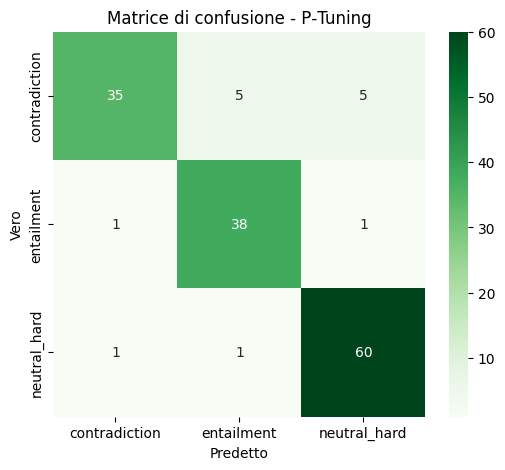

In [22]:
# --- Valutazione per P-Tuning ---
print("\n Metriche dettagliate per P‑Tuning sul test set")

predictions_pt = final_trainer_pt.predict(tokenized_ds["test"])
preds_pt = np.argmax(predictions_pt.predictions, axis=-1)

acc_pt = accuracy_score(refs, preds_pt)
prec_macro_pt = precision_score(refs, preds_pt, average='macro')
rec_macro_pt = recall_score(refs, preds_pt, average='macro')
f1_macro_pt = f1_score(refs, preds_pt, average='macro')

prec_weighted_pt = precision_score(refs, preds_pt, average='weighted')
rec_weighted_pt = recall_score(refs, preds_pt, average='weighted')
f1_weighted_pt = f1_score(refs, preds_pt, average='weighted')

print(f"P‑Tuning - trainable: {pt_trainable_params:,} | total: {pt_total_params:,} | trainable%: {pt_trainable_params/pt_total_params*100:.2f}%")
print(f"Accuracy: {acc_pt:.4f}")
print(f"Precision (macro): {prec_macro_pt:.4f} | Recall (macro): {rec_macro_pt:.4f} | F1 (macro): {f1_macro_pt:.4f}")
print(f"Precision (weighted): {prec_weighted_pt:.4f} | Recall (weighted): {rec_weighted_pt:.4f} | F1 (weighted): {f1_weighted_pt:.4f}")

print("\n Classification Report per classe (P‑Tuning):")
print(classification_report(refs, preds_pt, target_names=ID2LABEL.values()))

cm_pt = confusion_matrix(refs, preds_pt)
plt.figure(figsize=(6,5))
sns.heatmap(cm_pt, annot=True, fmt='d', cmap='Greens',
            xticklabels=ID2LABEL.values(), yticklabels=ID2LABEL.values())
plt.title("Matrice di confusione - P‑Tuning")
plt.xlabel("Predetto")
plt.ylabel("Vero")
plt.show()

In [23]:
print("\n--- CONFRONTO FINALE TRA APPROCCI ---")

comparison = {
    "Zero-Shot": {
        "Accuracy": zs_acc,
        "Precision (macro)": prec_macro_zs,
        "Recall (macro)": rec_macro_zs,
        "F1 (macro)": f1_macro_zs,
        "Precision (weighted)": prec_weighted_zs,
        "Recall (weighted)": rec_weighted_zs,
        "F1 (weighted)": f1_weighted_zs,
    },
    "LoRA": {
        "Accuracy": acc_lora,
        "Precision (macro)": prec_macro_lora,
        "Recall (macro)": rec_macro_lora,
        "F1 (macro)": f1_macro_lora,
        "Precision (weighted)": prec_weighted_lora,
        "Recall (weighted)": rec_weighted_lora,
        "F1 (weighted)": f1_weighted_lora,
    },
    "P‑Tuning": {
        "Accuracy": acc_pt,
        "Precision (macro)": prec_macro_pt,
        "Recall (macro)": rec_macro_pt,
        "F1 (macro)": f1_macro_pt,
        "Precision (weighted)": prec_weighted_pt,
        "Recall (weighted)": rec_weighted_pt,
        "F1 (weighted)": f1_weighted_pt,
    }
}

# Converti in DataFrame e mostra
df_comparison = pd.DataFrame(comparison).T.round(4)
display(df_comparison)


--- CONFRONTO FINALE TRA APPROCCI ---


,Accuracy,Precision (macro),Recall (macro),F1 (macro),Precision (weighted),Recall (weighted),F1 (weighted)
Zero-Shot,0.8980,0.8967,0.8952,0.8945,0.8982,0.8980,0.8968
LoRA,0.9796,0.9788,0.9778,0.9777,0.9803,0.9796,0.9794
P‑Tuning,0.9048,0.9062,0.8985,0.8986,0.9080,0.9048,0.9029


In [24]:
print("\n--- CONFRONTO FINALE TRA APPROCCI ---")
comparison = {
    "Baseline Zero-Shot": {"Accuracy": zs_acc, "Macro F1": zs_f1},
    f"LoRA (r={best_config['r']}, lr={best_config['lr']})": {
        "Accuracy": final_test_result['eval_accuracy'],
        "Macro F1": final_test_result['eval_macro_f1']
    },
    f"P‑Tuning (tokens={best_pt_config['num_tokens']}, lr={best_pt_config['lr']})": {
        "Accuracy": final_test_result_pt['eval_accuracy'],
        "Macro F1": final_test_result_pt['eval_macro_f1']
    }
}
display(pd.DataFrame(comparison).T)


--- CONFRONTO FINALE TRA APPROCCI ---


,Accuracy,Macro F1
Baseline Zero-Shot,0.897959,0.894452
"LoRA (r=8, lr=0.0003)",0.979592,0.977709
"P‑Tuning (tokens=16, lr=0.01)",0.904762,0.898640


In [25]:

print("\n--- SUCCESS ANALYSIS (Esempi classificati correttamente) ---")

logits = predictions_output.predictions
probs = np.exp(logits - logits.max(axis=-1, keepdims=True))
probs = probs / probs.sum(axis=-1, keepdims=True)

correct_idx = np.where(preds == refs)[0]

shown = []
for cls in ID2LABEL:                          
    cand = [i for i in correct_idx if refs[i] == cls]
    if cand:
        best = max(cand, key=lambda i: probs[i][cls])
        shown.append(best)

for i in shown:
    original = ds["test"][int(i)]
    conf = probs[i][preds[i]] * 100
    print("-" * 60)
    print(f"CONTESTO (Premise): {original['premise']}")
    print(f"CLAIM (Hypothesis): {original['hypothesis']}")
    print(f"ETICHETTA VERA: {ID2LABEL[refs[i]]} | PREDETTO: {ID2LABEL[preds[i]]} "
          f"(confidenza: {conf:.1f}%)")

print("-" * 60)
print(f"Totale corretti sul test: {len(correct_idx)}/{len(refs)} "
      f"({len(correct_idx)/len(refs)*100:.1f}%)")


--- SUCCESS ANALYSIS (Esempi classificati correttamente) ---
------------------------------------------------------------
CONTESTO (Premise): A Tokyo il mercato esterno di Tsukiji vive di mattina: le bancarelle iniziano ad aprire verso le 5:00 e la maggior parte delle attività abbassa le serrande nel primo pomeriggio, attorno alle 14:00.
CLAIM (Hypothesis): Il mercato esterno di Tsukiji apre solo la sera.
ETICHETTA VERA: contradiction | PREDETTO: contradiction (confidenza: 99.8%)
------------------------------------------------------------
CONTESTO (Premise): Mangiare in Giappone può essere economico: un pasto in una catena di gyudon come Yoshinoya o Sukiya costa circa 500-700 yen, mentre un ramen in un locale medio si aggira sui 1000 yen.
CLAIM (Hypothesis): In Giappone si può mangiare in modo economico nelle catene di gyudon.
ETICHETTA VERA: entailment | PREDETTO: entailment (confidenza: 100.0%)
------------------------------------------------------------
CONTESTO (Premise): A Gion,

In [26]:
import shutil
import os

export_folder = "./fact_checker_lora_model"

print(f"💾 Salvataggio dei pesi LoRA e del Tokenizer in '{export_folder}'...")
final_model.save_pretrained(export_folder)
tokenizer.save_pretrained(export_folder)

zip_filename = "fact_checker_lora"
shutil.make_archive(zip_filename, 'zip', export_folder)
print(f"✅ Archivio creato con successo: {zip_filename}.zip (Dimensione: {os.path.getsize(zip_filename + '.zip') / (1024*1024):.2f} MB)")

💾 Salvataggio dei pesi LoRA e del Tokenizer in './fact_checker_lora_model'...
✅ Archivio creato con successo: fact_checker_lora.zip (Dimensione: 5.10 MB)
